# NetCDF File Visualization
This notebook reads and visualizes the contents of CW2019_1579.nc

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Load the NetCDF file
nc_path = "../../datasets/processed/CW2019_1524.nc"
ds = xr.open_dataset(nc_path)
ds

<xarray.Dataset> Size: 1GB
Dimensions:     (time: 153, channel: 7, y: 512, x: 512)
Coordinates:
  * time        (time) datetime64[ns] 1kB 2019-05-01 2019-05-02 ... 2019-09-30
  * channel     (channel) <U6 168B 'red' 'green' 'blue' ... 'swir22' 'mask'
    lake_id     <U11 44B ...
Dimensions without coordinates: y, x
Data variables:
    imagery     (time, channel, y, x) float32 1GB ...
    water_area  (time) float64 1kB ...
Attributes:
    description:     Combined lake drainage dataset
    lake_id:         CW2019_1524
    year:            2019
    source_imagery:  /oak/stanford/groups/cyaolai/JoshRines/data/tstacks/CW20...
    channels:        red, green, blue, nir, swir16, swir22, mask

In [7]:
print(ds['imagery'].min(), ds['imagery'].max())

<xarray.DataArray 'imagery' ()> Size: 4B
array(0., dtype=float32)
Coordinates:
    lake_id  <U11 44B ... <xarray.DataArray 'imagery' ()> Size: 4B
array(15040., dtype=float32)
Coordinates:
    lake_id  <U11 44B ...


In [3]:
# List all variables and their dimensions
print("Variables:")
for var in ds.data_vars:
    print(f"  {var}: {ds[var].dims} - shape {ds[var].shape}")

print("\nCoordinates:")
for coord in ds.coords:
    print(f"  {coord}: {ds[coord].shape}")

Variables:
  imagery: ('time', 'channel', 'y', 'x') - shape (153, 4, 512, 512)
  water_area: ('time',) - shape (153,)

Coordinates:
  time: (153,)
  channel: (4,)
  lake_id: ()


In [4]:
# Show global attributes
print("Global Attributes:")
for attr, value in ds.attrs.items():
    print(f"  {attr}: {value}")

Global Attributes:
  description: Combined lake drainage dataset
  lake_id: CW2019_1579
  year: 2019
  source_imagery: ../datasets/imgseqs/tstack_CW2019_1579.nc


In [5]:
# Visualize the first 2D or 3D variable
for var_name in ds.data_vars:
    var = ds[var_name]
    ndims = len(var.dims)
    
    if ndims == 2:
        fig, ax = plt.subplots(figsize=(10, 8))
        var.plot(ax=ax, cmap='viridis')
        ax.set_title(f"{var_name}")
        plt.tight_layout()
        plt.show()
        break
    elif ndims == 3:
        # Plot first slice of 3D variable
        fig, ax = plt.subplots(figsize=(10, 8))
        var.isel({var.dims[0]: 0}).plot(ax=ax, cmap='viridis')
        ax.set_title(f"{var_name} (first slice)")
        plt.tight_layout()
        plt.show()
        break

AttributeError: Rectangle.set() got an unexpected keyword argument 'cmap'

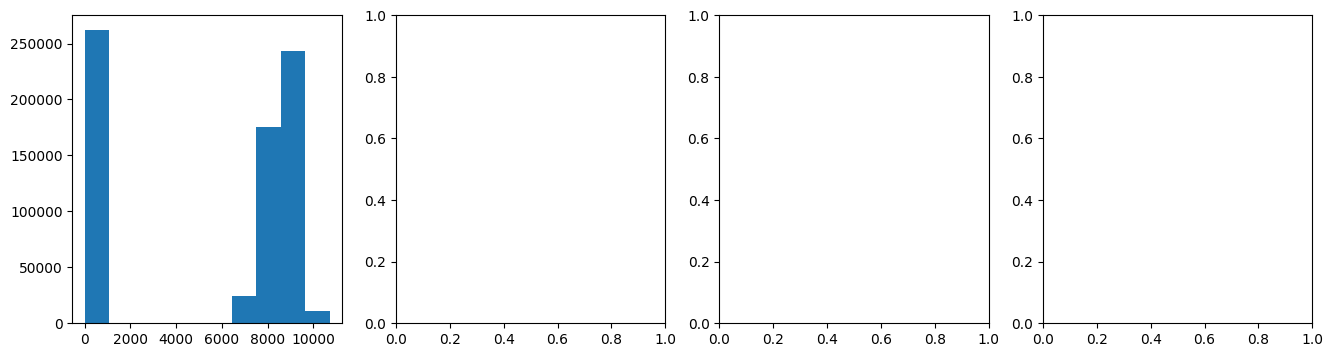

In [6]:
# Visualize all 2D/3D variables
for var_name in ds.data_vars:
    var = ds[var_name]
    ndims = len(var.dims)
    
    if ndims == 2:
        fig, ax = plt.subplots(figsize=(8, 6))
        var.plot(ax=ax, cmap='viridis')
        ax.set_title(f"{var_name}")
        plt.tight_layout()
        plt.show()
    elif ndims >= 3:
        # For 3D+ variables, show a few time slices if time dimension exists
        first_dim = var.dims[0]
        n_slices = min(4, var.shape[0])
        
        fig, axes = plt.subplots(1, n_slices, figsize=(4*n_slices, 4))
        if n_slices == 1:
            axes = [axes]
        
        for i, ax in enumerate(axes):
            var.isel({first_dim: i}).plot(ax=ax, cmap='viridis', add_colorbar=True)
            ax.set_title(f"{var_name}[{first_dim}={i}]")
        
        plt.tight_layout()
        plt.show()

In [ ]:
ds.close()